In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "Kaushal singh tomar",\r\n  "key": "KGAT_d3e219be09d42edde341253d39200e3c"\r\n}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets list -s galaxy-zoo


ref                                       title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jaimetrickz/galaxy-zoo-2-images           Galaxy Zoo 2: Images                           3281862708  2021-01-26 16:25:27.667000           8681         34  0.9411765        
robertmifsud/resized-reduced-gz2-images   Resized and Reduced Galaxy Zoo 2 Images        1934213890  2023-05-25 23:12:04.167000            694          6  0.8235294        
anjosut/galaxy-zoo-classification         Galaxy Zoo classification                       397550426  2023-04-08 04:28:53.070000            631          3  0.3529412        
zhuangjw/galaxy-zoo-cleaned               galaxy_zoo_cleaned                             2352353415  2019-11-03 16:46:51.047000        

In [4]:
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:16<00:00, 193MB/s]



In [5]:
!ls

galaxy-zoo-2-images.zip  kaggle.json  sample_data


In [6]:
!unzip -q galaxy-zoo-2-images.zip -d galaxy_raw

In [7]:
!ls galaxy_raw

gz2_filename_mapping.csv  images_gz2


In [8]:
import os
print(os.listdir("galaxy_raw"))

['images_gz2', 'gz2_filename_mapping.csv']


In [9]:
import pandas as pd
mapping = pd.read_csv("galaxy_raw/gz2_filename_mapping.csv")
mapping.head()

,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5


In [10]:
print(mapping.columns)

Index(['objid', 'sample', 'asset_id'], dtype='object')


In [11]:
!wget -O galaxy_raw/gz2_hart16.csv.gz \
https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz

--2026-06-05 19:28:26--  https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Resolving gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)... 16.15.223.180, 52.216.220.97, 16.15.191.47, ...
Connecting to gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)|16.15.223.180|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78513011 (75M) [application/x-gzip]
Saving to: ‘galaxy_raw/gz2_hart16.csv.gz’

galaxy_raw/gz2_hart 100%[===================>]  74.88M  36.6MB/s    in 2.0s    

2026-06-05 19:28:28 (36.6 MB/s) - ‘galaxy_raw/gz2_hart16.csv.gz’ saved [78513011/78513011]



In [12]:
!gunzip galaxy_raw/gz2_hart16.csv.gz

In [13]:
!ls galaxy_raw

gz2_filename_mapping.csv  gz2_hart16.csv  images_gz2


In [14]:
labels = pd.read_csv(
    "galaxy_raw/gz2_hart16.csv"
)

labels.head()

,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


In [15]:
print(labels.columns.tolist())

['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction', 't01_smooth_or_features_a03_star_or_artifact_d

In [16]:
def high_level_label(gz2_class):

    if pd.isna(gz2_class):
        return None

    gz2_class = str(gz2_class)

    if gz2_class.startswith("E"):
        return "elliptical"

    if gz2_class.startswith("SB"):
        return "spiral_barred"

    if gz2_class.startswith("S"):
        return "spiral"

    if gz2_class.startswith("A"):
        return None

    return None

In [17]:
print(high_level_label("Ei"))
print(high_level_label("Er"))
print(high_level_label("SBa"))
print(high_level_label("Sc+t"))
print(high_level_label("A"))

elliptical
elliptical
spiral_barred
spiral
None


In [18]:
mapping = pd.read_csv(
    "galaxy_raw/gz2_filename_mapping.csv"
)

labels = pd.read_csv(
    "galaxy_raw/gz2_hart16.csv"
)

In [19]:
merged = mapping.merge(
    labels,
    left_on="objid",
    right_on="dr7objid"
)

print(merged.shape)

(239695, 234)


In [21]:
merged[
    ["asset_id", "objid", "gz2_class"]
].head()

,asset_id,objid,gz2_class
0,3,587722981741363294,Sb
1,4,587722981741363323,Sc?l
2,5,587722981741559888,Er
3,6,587722981741625481,Sc1t
4,7,587722981741625484,Sb


In [20]:
merged["label"] = merged[
    "gz2_class"
].apply(high_level_label)

In [22]:
print(
    merged["label"]
    .value_counts(dropna=False)
)

label
elliptical       97670
spiral           95849
spiral_barred    45581
None               595
Name: count, dtype: int64


In [23]:
merged["label"].value_counts()

,count
label,
elliptical,97670
spiral,95849
spiral_barred,45581


In [24]:
import os

os.makedirs(
    "galaxy_data/elliptical",
    exist_ok=True
)

os.makedirs(
    "galaxy_data/spiral",
    exist_ok=True
)

os.makedirs(
    "galaxy_data/spiral_barred",
    exist_ok=True
)

print("Folders created")

Folders created


In [25]:
subset = (
    merged
    .groupby("label")
    .sample(
        n=1500,
        random_state=42
    )
)

print(
    subset["label"]
    .value_counts()
)

label
elliptical       1500
spiral           1500
spiral_barred    1500
Name: count, dtype: int64


In [27]:
import os

print(
    os.listdir(
        "galaxy_raw/images_gz2/images"
    )[:10]
)

['135418.jpg', '179026.jpg', '62305.jpg', '217760.jpg', '180837.jpg', '245723.jpg', '166595.jpg', '65176.jpg', '73541.jpg', '209431.jpg']


In [28]:
import shutil
import os

source_dir = "galaxy_raw/images_gz2/images"

copied = 0

for _, row in subset.iterrows():

    asset_id = row["asset_id"]
    label = row["label"]

    source_file = os.path.join(
        source_dir,
        f"{asset_id}.jpg"
    )

    destination_file = os.path.join(
        "galaxy_data",
        label,
        f"{asset_id}.jpg"
    )

    if os.path.exists(source_file):

        shutil.copy(
            source_file,
            destination_file
        )

        copied += 1

print("Copied:", copied)

Copied: 4499


In [29]:
print(
    len(os.listdir("galaxy_data/elliptical"))
)

print(
    len(os.listdir("galaxy_data/spiral"))
)

print(
    len(os.listdir("galaxy_data/spiral_barred"))
)

1500
1500
1499


In [30]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [31]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root="galaxy_data",
    transform=transform
)

print(dataset.classes)

print(len(dataset))

['elliptical', 'spiral', 'spiral_barred']
4499


In [32]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

print(loader)

In [33]:
images, labels = next(iter(loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 128, 128])
torch.Size([16])


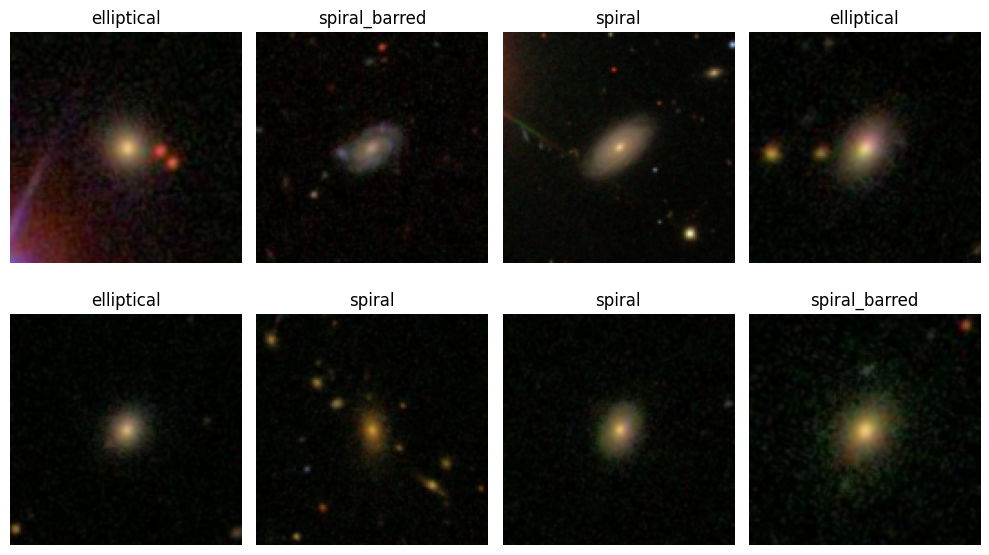

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    4,
    figsize=(10, 6)
)

for i, ax in enumerate(axes.flat):

    image = images[i]

    image = image.permute(1, 2, 0)

    image = image * 0.5 + 0.5

    ax.imshow(image)

    ax.set_title(
        dataset.classes[
            labels[i]
        ]
    )

    ax.axis("off")

plt.tight_layout()

plt.show()